In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_2_11.2_50.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-422.0,-0.0175,0.000289,-72.6,-1.160000e-09,-8.240000e-08,-1.350000e-09,4910.0,4910.0
1,0.2,-402.0,-0.2550,0.000348,-277.0,-1.430000e-07,2.830000e-03,-1.320000e-07,4690.0,4650.0
2,0.3,-380.0,1.2500,-0.035900,-413.0,-2.880000e-06,1.940000e-02,2.190000e-07,4650.0,4380.0
3,0.4,-356.0,4.1700,-0.070800,-339.0,-1.250000e-06,2.620000e-02,1.160000e-06,4790.0,4420.0
4,0.5,-330.0,3.0200,-0.097500,-242.0,4.580000e-07,2.310000e-02,2.060000e-06,4880.0,4550.0


In [3]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-4.22e+02 -1.75e-02  2.89e-04 ... -1.35e-09  4.91e+03  4.91e+03]
 [-4.02e+02 -2.55e-01  3.48e-04 ... -1.32e-07  4.69e+03  4.65e+03]
 [-3.80e+02  1.25e+00 -3.59e-02 ...  2.19e-07  4.65e+03  4.38e+03]
 ...
 [-2.13e+02 -1.20e+02 -5.24e-01 ...  2.37e-04  4.16e+03  5.16e+03]
 [-2.31e+02 -1.22e+02 -2.43e-01 ...  2.07e-04  4.14e+03  5.17e+03]
 [-2.49e+02 -1.22e+02 -6.28e-01 ...  8.97e-05  4.12e+03  5.17e+03]]
(40000, 9)


In [4]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [5]:
# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [6]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [7]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
# 归一化后的两个数据集
# 波浪-运动响应
# # Force
# # 输入50步长输出1步长
# force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
# force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# # 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)



# # 输入50步长输出3步长
# force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
# force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
# print(force150_x3.shape)
# # 输入100步长输出3步长
# force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
# force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
# print(force1100_x3.shape)



# # 输入50步长输出5步长
# force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
# force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
# print(force150_x5.shape)
# # 输入100步长输出5步长
# force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
# force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
# print(force1100_x5.shape)



# # 输入50步长输出7步长
# force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
# force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
# print(force150_x7.shape)
# # 输入100步长输出7步长
# force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
# force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
# print(force1100_x7.shape)



# # 输入50步长输出9步长
# force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
# force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
# print(force150_x9.shape)
# # 输入100步长输出9步长
# force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
# force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
# print(force1100_x9.shape)



# 输入50步长输出2步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x1,force150_y1 = split_sequence(force150_scaled2, 50)
print(force150_x1.shape)
# 输入100步长输出2步长
force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled2, 100)
print(force1100_x1.shape)


# 输入50步长输出4步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x2,force150_y2 = split_sequence(force150_scaled4, 50)
print(force150_x2.shape)
# 输入100步长输出4步长
force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
force1100_x2,force1100_y2 = split_sequence(force1100_scaled4, 100)
print(force1100_x2.shape)



# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x3,force150_y3 = split_sequence(force150_scaled6, 50)
print(force150_x3.shape)
# 输入100步长输出6步长
force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
force1100_x3,force1100_y3 = split_sequence(force1100_scaled6, 100)
print(force1100_x3.shape)



# 输入50步长输出8步长
force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x4,force150_y4 = split_sequence(force150_scaled8, 50)
print(force150_x4.shape)
# 输入100步长输出8步长
force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
force1100_x4,force1100_y4 = split_sequence(force1100_scaled8, 100)
print(force1100_x4.shape)




(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)
(39551, 50, 3)
(39501, 100, 3)


In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# # 输入50步长输出1步长
# heave50_scaled1 = deal_data2(np.hstack((H,Heave))[350:,:], 2, 50)
# heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 50)
# print(heave50_x1.shape)
# # 输入100步长输出1步长
# heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
# heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
# print(heave100_x1.shape)



# # 输入50步长输出3步长
# heave50_scaled3 = deal_data2(np.hstack((H,Heave))[348:,:], 2, 52)
# heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 50)
# print(heave50_x3.shape)
# # 输入100步长输出3步长
# heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
# heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
# print(heave100_x3.shape)



# # 输入50步长输出5步长
# heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
# heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
# print(heave50_x5.shape)
# # 输入100步长输出5步长
# heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
# heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
# print(heave100_x5.shape)



# # 输入50步长输出7步长
# heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
# heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
# print(heave50_x7.shape)
# # 输入100步长输出7步长
# heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
# heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
# print(heave100_x7.shape)



# # 输入50步长输出9步长
# heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
# heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
# print(heave50_x9.shape)
# # 输入100步长输出9步长
# heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
# heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
# print(heave100_x9.shape)



# 输入50步长输出2步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[349:,:], 2, 51)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled2, 50)
print(heave50_x1.shape)
# 输入100步长输出2步长
# heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
# heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
# print(heave100_x2.shape)


# 输入50步长输出4步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[347:,:], 2, 53)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled4, 50)
print(heave50_x2.shape)
# 输入100步长输出4步长
# heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
# heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
# print(heave100_x4.shape)



# 输入50步长输出6步长
heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled6, 50)
print(heave50_x3.shape)
# 输入100步长输出6步长
# heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
# heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
# print(heave100_x6.shape)



# 输入50步长输出8步长
heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled8, 50)
print(heave50_x4.shape)
# # 输入100步长输出8步长
# heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
# heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
# print(heave100_x8.shape)


# # Surge
# # 输入50步长输出1步长
# surge50_scaled1 = deal_data2(np.hstack((H,Surge))[350:,:], 2, 50)
# surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 50)
# print(surge50_x1.shape)
# # 输入100步长输出1步长
# surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
# surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
# print(surge100_x1.shape)



# # 输入50步长输出3步长
# surge50_scaled3 = deal_data2(np.hstack((H,Surge))[348:,:], 2, 52)
# surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 50)
# print(surge50_x3.shape)
# # 输入100步长输出3步长
# surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
# surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
# print(surge100_x3.shape)



# # 输入50步长输出5步长
# surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
# surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
# print(surge50_x5.shape)
# # 输入100步长输出5步长
# surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
# surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
# print(surge100_x5.shape)



# # 输入50步长输出7步长
# surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
# surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
# print(surge50_x7.shape)
# # 输入100步长输出7步长
# surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
# surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
# print(surge100_x7.shape)



# # 输入50步长输出9步长
# surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
# surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
# print(surge50_x9.shape)
# # 输入100步长输出9步长
# surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
# surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
# print(surge100_x9.shape)



# 输入50步长输出2步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[349:,:], 2, 51)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled2, 50)
print(surge50_x1.shape)
# 输入100步长输出2步长
# surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
# surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
# print(surge100_x2.shape)


# 输入50步长输出4步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[347:,:], 2, 53)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled4, 50)
print(surge50_x2.shape)
# 输入100步长输出4步长
# surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
# surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
# print(surge100_x4.shape)



# 输入50步长输出6步长
surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled6, 50)
print(surge50_x3.shape)
# 输入100步长输出6步长
# surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
# surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
# print(surge100_x6.shape)



# 输入50步长输出8步长
surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled8, 50)
print(surge50_x4.shape)
# 输入100步长输出8步长
# surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
# surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
# print(surge100_x8.shape)


# # Pitch
# # 输入50步长输出1步长
# pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[350:,:], 2, 50)
# pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 50)
# print(pitch50_x1.shape)
# # 输入100步长输出1步长
# pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
# pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
# print(pitch100_x1.shape)



# # 输入50步长输出3步长
# pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[348:,:], 2, 52)
# pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 50)
# print(pitch50_x3.shape)
# # 输入100步长输出3步长
# pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
# pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
# print(pitch100_x3.shape)



# # 输入50步长输出5步长
# pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
# pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
# print(pitch50_x5.shape)
# # 输入100步长输出5步长
# pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
# pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
# print(pitch100_x5.shape)



# # 输入50步长输出7步长
# pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
# pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
# print(pitch50_x7.shape)
# # 输入100步长输出7步长
# pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
# pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
# print(pitch100_x7.shape)



# # 输入50步长输出9步长
# pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
# pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
# print(pitch50_x9.shape)
# # 输入100步长输出9步长
# pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
# pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
# print(pitch100_x9.shape)



# 输入50步长输出2步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[349:,:], 2, 51)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled2, 50)
print(pitch50_x1.shape)
# # 输入100步长输出2步长
# pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
# pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
# print(pitch100_x2.shape)


# 输入50步长输出4步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[347:,:], 2, 53)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled4, 50)
print(pitch50_x2.shape)
# # 输入100步长输出4步长
# pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
# pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
# print(pitch100_x4.shape)



# 输入50步长输出6步长
pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled6, 50)
print(pitch50_x3.shape)
# # 输入100步长输出6步长
# pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
# pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
# print(pitch100_x6.shape)



# 输入50步长输出8步长
pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled8, 50)
print(pitch50_x4.shape)
# # 输入100步长输出8步长
# pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
# pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
# print(pitch100_x8.shape)

(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)
(39551, 50, 1)


#### 系泊缆力联合预测（时间窗50输出；步长2）

In [10]:
# 未来运动预测模型建立
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 6900, 7500, 12500)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 6600, 7500, 12500)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 6900, 7500, 12500)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 169s - loss: 0.0630 - val_loss: 0.0510 - 169s/epoch - 14s/step
Epoch 2/30
12/12 - 0s - loss: 0.0348 - val_loss: 0.0295 - 301ms/epoch - 25ms/step
Epoch 3/30
12/12 - 0s - loss: 0.0209 - val_loss: 0.0204 - 302ms/epoch - 25ms/step
Epoch 4/30
12/12 - 0s - loss: 0.0145 - val_loss: 0.0144 - 300ms/epoch - 25ms/step
Epoch 5/30
12/12 - 0s - loss: 0.0100 - val_loss: 0.0099 - 298ms/epoch - 25ms/step
Epoch 6/30
12/12 - 0s - loss: 0.0068 - val_loss: 0.0066 - 307ms/epoch - 26ms/step
Epoch 7/30
12/12 - 0s - loss: 0.0048 - val_loss: 0.0054 - 303ms/epoch - 25ms/step
Epoch 8/30
12/12 - 0s - loss: 0.0044 - val_loss: 0.0053 - 302ms/epoch - 25ms/step
Epoch 9/30
12/12 - 0s - loss: 0.0043 - val_loss: 0.0052 - 299ms/epoch - 25ms/step
Epoch 10/30
12/12 - 0s - loss: 0.0042 - val_loss: 0.0051 - 303ms/epoch - 25ms/step
Epoch 11/30
12/12 - 0s - loss: 0.0041 - val_loss: 0.0050 - 304ms/epoch - 25ms/step
Epoch 12/30
12/12 - 0s - loss: 0.0041 - val_loss: 0.0050 - 296ms/epoch - 25ms/step
Epoch 13/30
12/12 - 0s -

In [11]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

19/19 [==============================] - 0s 3ms/step
(600, 1)
(600, 1)
(600, 1)


In [12]:
# 输入50步长输出1步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [13]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 6900, 7500, 12500)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [14]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0446 - val_loss: 0.0258 - 342ms/epoch - 114ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0286 - val_loss: 0.0211 - 43ms/epoch - 14ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0184 - val_loss: 0.0124 - 39ms/epoch - 13ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0141 - val_loss: 0.0154 - 38ms/epoch - 13ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0128 - val_loss: 0.0121 - 41ms/epoch - 14ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0109 - val_loss: 0.0139 - 38ms/epoch - 13ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0136 - val_loss: 0.0141 - 38ms/epoch - 13ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0134 - val_loss: 0.0108 - 39ms/epoch - 13ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0110 - val_loss: 0.0100 - 39ms/epoch - 13ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0103 - val_loss: 0.0102 - 40ms/epoch - 13ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0100 - val_loss: 0.0100 - 44ms/epoch - 15ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0097 - val_loss: 0.0106 - 42ms/epoch - 14ms/step
Epoch 13/1000
3/3 - 0s 

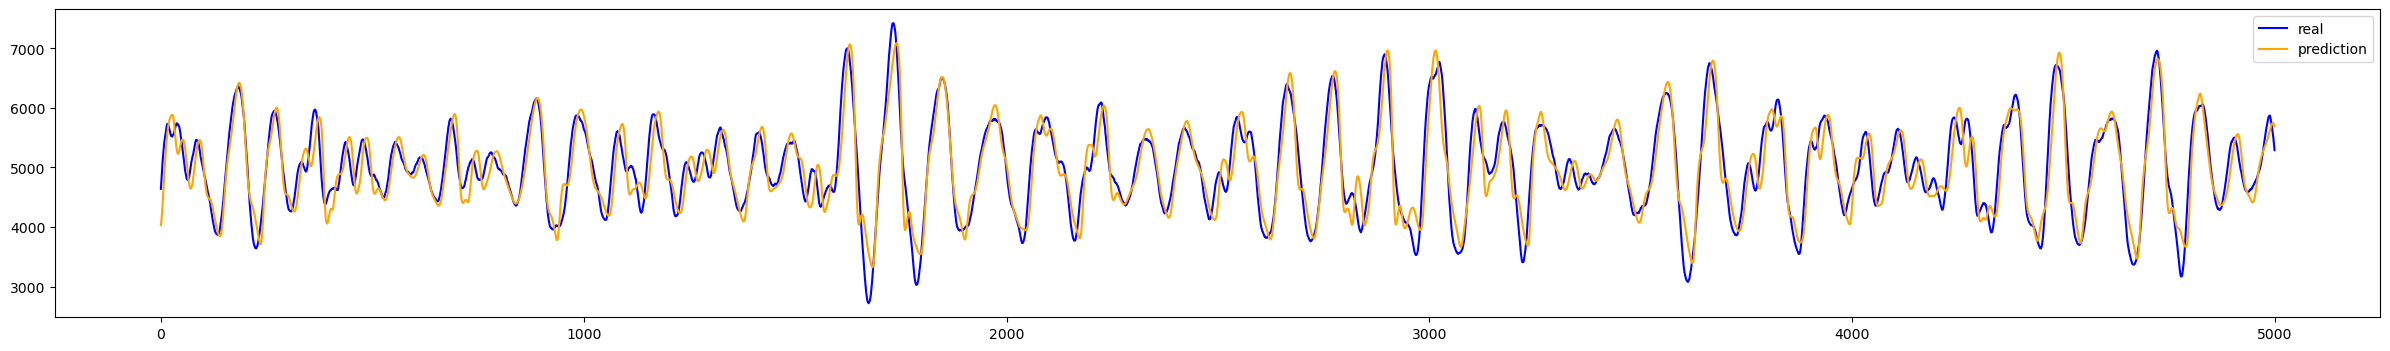

Acc: 0.9549348705842794


In [15]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force150_步长1.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [16]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[349:,:], 4, 51)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [17]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 6900, 7500, 12500)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [18]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1157 - val_loss: 0.0437 - 323ms/epoch - 108ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0550 - val_loss: 0.0586 - 51ms/epoch - 17ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0514 - val_loss: 0.0385 - 40ms/epoch - 13ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0446 - val_loss: 0.0430 - 44ms/epoch - 15ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0523 - val_loss: 0.0456 - 43ms/epoch - 14ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0526 - val_loss: 0.0416 - 44ms/epoch - 15ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0472 - val_loss: 0.0387 - 43ms/epoch - 14ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0435 - val_loss: 0.0384 - 43ms/epoch - 14ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0424 - val_loss: 0.0374 - 38ms/epoch - 13ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0414 - val_loss: 0.0361 - 43ms/epoch - 14ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0412 - val_loss: 0.0368 - 41ms/epoch - 14ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0425 - val_loss: 0.0375 - 42ms/epoch - 14ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.042

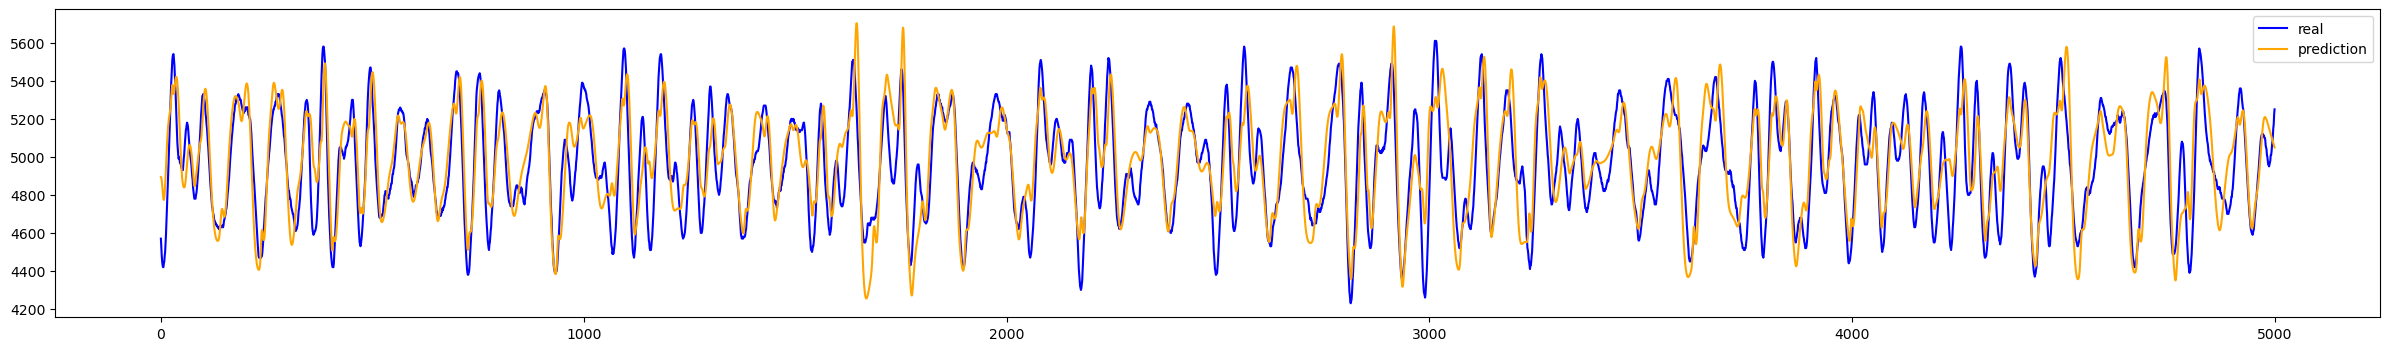

Acc: 0.9611539695827523


In [19]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force250_步长1.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长4）

In [20]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 6900, 7500, 12500)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_LSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 6600, 7500, 12500)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_LSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 6900, 7500, 12500)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_LSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 1s - loss: 0.0590 - val_loss: 0.0508 - 1s/epoch - 94ms/step
Epoch 2/30
12/12 - 0s - loss: 0.0367 - val_loss: 0.0350 - 306ms/epoch - 26ms/step
Epoch 3/30
12/12 - 0s - loss: 0.0260 - val_loss: 0.0264 - 315ms/epoch - 26ms/step
Epoch 4/30
12/12 - 0s - loss: 0.0191 - val_loss: 0.0190 - 313ms/epoch - 26ms/step
Epoch 5/30
12/12 - 0s - loss: 0.0137 - val_loss: 0.0129 - 314ms/epoch - 26ms/step
Epoch 6/30
12/12 - 0s - loss: 0.0094 - val_loss: 0.0086 - 311ms/epoch - 26ms/step
Epoch 7/30
12/12 - 0s - loss: 0.0074 - val_loss: 0.0080 - 314ms/epoch - 26ms/step
Epoch 8/30
12/12 - 0s - loss: 0.0072 - val_loss: 0.0078 - 312ms/epoch - 26ms/step
Epoch 9/30
12/12 - 0s - loss: 0.0066 - val_loss: 0.0076 - 315ms/epoch - 26ms/step
Epoch 10/30
12/12 - 0s - loss: 0.0064 - val_loss: 0.0076 - 310ms/epoch - 26ms/step
Epoch 11/30
12/12 - 0s - loss: 0.0063 - val_loss: 0.0074 - 316ms/epoch - 26ms/step
Epoch 12/30
12/12 - 0s - loss: 0.0061 - val_loss: 0.0073 - 313ms/epoch - 26ms/step
Epoch 13/30
12/12 - 0s - lo

In [21]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

19/19 [==============================] - 0s 2ms/step
(600, 1)
(600, 1)
(600, 1)


In [22]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [23]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 6900, 7500, 12500)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [24]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0386 - val_loss: 0.0355 - 434ms/epoch - 145ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0326 - val_loss: 0.0186 - 44ms/epoch - 15ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0169 - val_loss: 0.0175 - 43ms/epoch - 14ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0154 - val_loss: 0.0166 - 43ms/epoch - 14ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0122 - val_loss: 0.0158 - 42ms/epoch - 14ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0134 - val_loss: 0.0193 - 46ms/epoch - 15ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0163 - val_loss: 0.0165 - 45ms/epoch - 15ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0135 - val_loss: 0.0144 - 43ms/epoch - 14ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0116 - val_loss: 0.0147 - 44ms/epoch - 15ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0111 - val_loss: 0.0148 - 42ms/epoch - 14ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0111 - val_loss: 0.0156 - 40ms/epoch - 13ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0122 - val_loss: 0.0164 - 42ms/epoch - 14ms/step
Epoch 13/1000
3/3 - 0s 

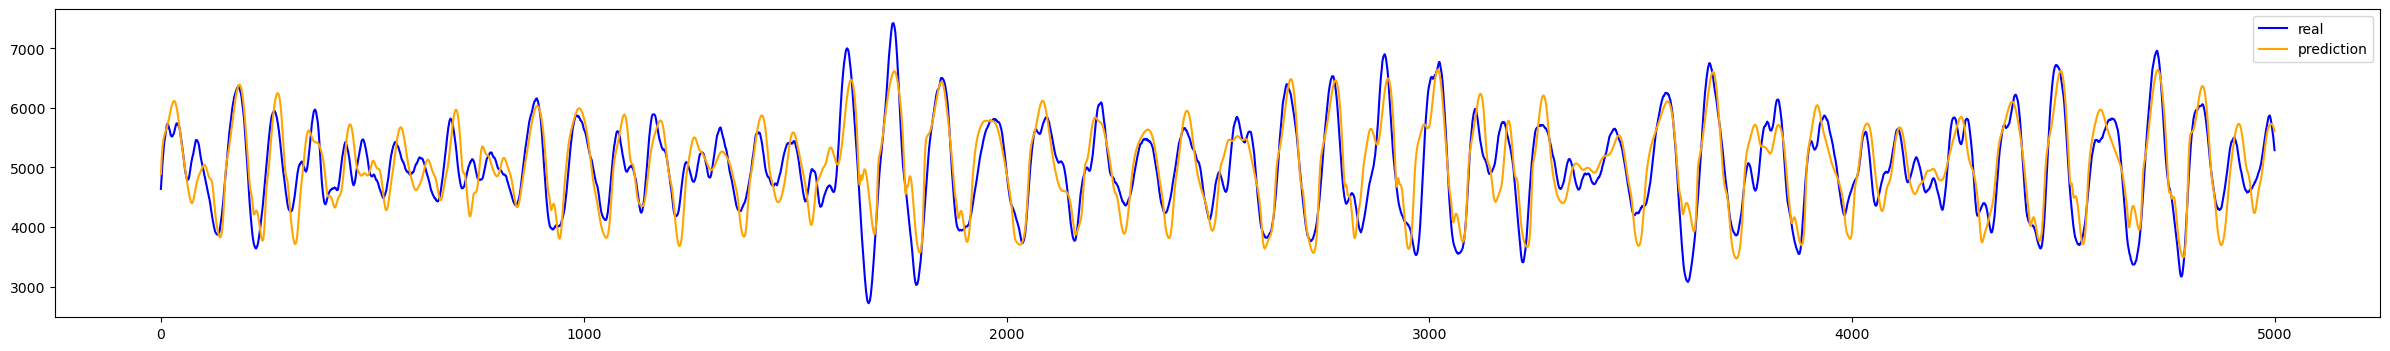

Acc: 0.9760934209789717


In [25]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force150_步长2.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [26]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[347:,:], 4, 53)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [27]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 6900, 7500, 12500)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [28]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1188 - val_loss: 0.0490 - 254ms/epoch - 85ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0592 - val_loss: 0.0636 - 41ms/epoch - 14ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0555 - val_loss: 0.0410 - 40ms/epoch - 13ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0439 - val_loss: 0.0434 - 39ms/epoch - 13ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0489 - val_loss: 0.0458 - 36ms/epoch - 12ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0480 - val_loss: 0.0386 - 39ms/epoch - 13ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0393 - val_loss: 0.0342 - 41ms/epoch - 14ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0338 - val_loss: 0.0348 - 40ms/epoch - 13ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0310 - val_loss: 0.0328 - 37ms/epoch - 12ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0284 - val_loss: 0.0336 - 37ms/epoch - 12ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0299 - val_loss: 0.0353 - 36ms/epoch - 12ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0301 - val_loss: 0.0347 - 38ms/epoch - 13ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0276

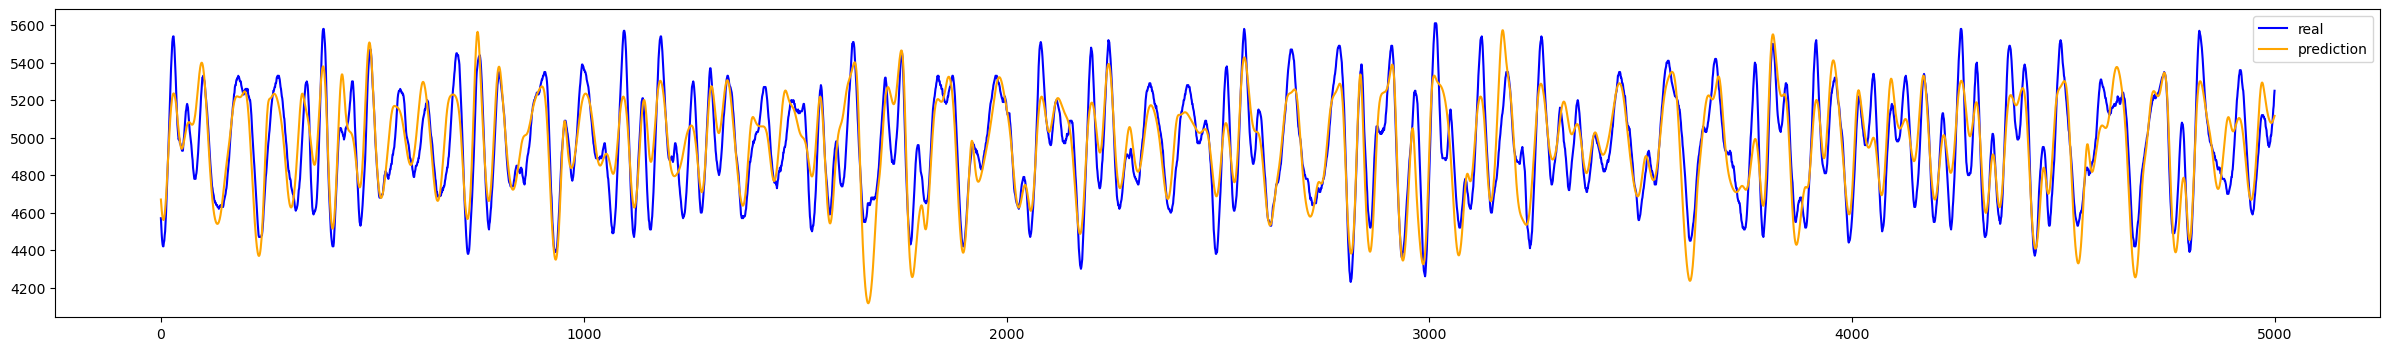

Acc: 0.9353761898352548


In [29]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force250_步长2.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长6）

In [30]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 6900, 7500, 12500)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_LSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 6600, 7500, 12500)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_LSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 6900, 7500, 12500)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_LSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 1s - loss: 0.0576 - val_loss: 0.0537 - 1s/epoch - 91ms/step
Epoch 2/30
12/12 - 0s - loss: 0.0409 - val_loss: 0.0413 - 325ms/epoch - 27ms/step
Epoch 3/30
12/12 - 0s - loss: 0.0323 - val_loss: 0.0349 - 298ms/epoch - 25ms/step
Epoch 4/30
12/12 - 0s - loss: 0.0272 - val_loss: 0.0296 - 315ms/epoch - 26ms/step
Epoch 5/30
12/12 - 0s - loss: 0.0229 - val_loss: 0.0247 - 305ms/epoch - 25ms/step
Epoch 6/30
12/12 - 0s - loss: 0.0190 - val_loss: 0.0197 - 313ms/epoch - 26ms/step
Epoch 7/30
12/12 - 0s - loss: 0.0148 - val_loss: 0.0142 - 312ms/epoch - 26ms/step
Epoch 8/30
12/12 - 0s - loss: 0.0109 - val_loss: 0.0100 - 332ms/epoch - 28ms/step
Epoch 9/30
12/12 - 0s - loss: 0.0088 - val_loss: 0.0095 - 320ms/epoch - 27ms/step
Epoch 10/30
12/12 - 0s - loss: 0.0085 - val_loss: 0.0092 - 307ms/epoch - 26ms/step
Epoch 11/30
12/12 - 0s - loss: 0.0079 - val_loss: 0.0092 - 311ms/epoch - 26ms/step
Epoch 12/30
12/12 - 0s - loss: 0.0076 - val_loss: 0.0090 - 313ms/epoch - 26ms/step
Epoch 13/30
12/12 - 0s - lo

In [31]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

19/19 [==============================] - 0s 2ms/step
(600, 1)
(600, 1)
(600, 1)


In [32]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [33]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 6900, 7500, 12500)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [34]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0456 - val_loss: 0.0355 - 314ms/epoch - 105ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0333 - val_loss: 0.0287 - 48ms/epoch - 16ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0239 - val_loss: 0.0183 - 46ms/epoch - 15ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0174 - val_loss: 0.0212 - 41ms/epoch - 14ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0159 - val_loss: 0.0179 - 40ms/epoch - 13ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0137 - val_loss: 0.0197 - 39ms/epoch - 13ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0167 - val_loss: 0.0217 - 40ms/epoch - 13ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0180 - val_loss: 0.0190 - 46ms/epoch - 15ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0156 - val_loss: 0.0175 - 43ms/epoch - 14ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0142 - val_loss: 0.0177 - 42ms/epoch - 14ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0138 - val_loss: 0.0174 - 48ms/epoch - 16ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0135 - val_loss: 0.0177 - 43ms/epoch - 14ms/step
Epoch 13/1000
3/3 - 0s 

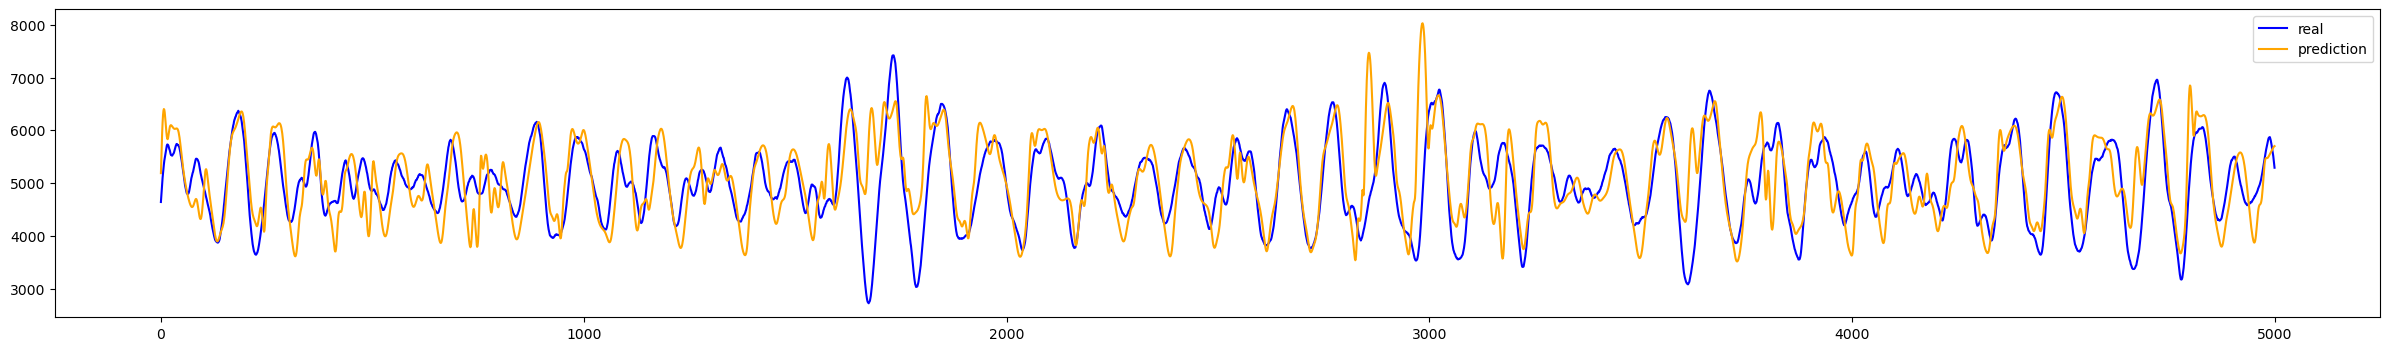

Acc: 0.914245004006091


In [35]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force150_步长3.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [36]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[345:,:], 4, 55)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [37]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 6900, 7500, 12500)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [38]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1456 - val_loss: 0.0532 - 292ms/epoch - 97ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0659 - val_loss: 0.0759 - 50ms/epoch - 17ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0637 - val_loss: 0.0434 - 48ms/epoch - 16ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0471 - val_loss: 0.0467 - 49ms/epoch - 16ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0543 - val_loss: 0.0500 - 47ms/epoch - 16ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0539 - val_loss: 0.0422 - 43ms/epoch - 14ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0440 - val_loss: 0.0383 - 48ms/epoch - 16ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0380 - val_loss: 0.0394 - 50ms/epoch - 17ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0353 - val_loss: 0.0365 - 44ms/epoch - 15ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0321 - val_loss: 0.0349 - 41ms/epoch - 14ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0330 - val_loss: 0.0372 - 40ms/epoch - 13ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0352 - val_loss: 0.0372 - 47ms/epoch - 16ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0330

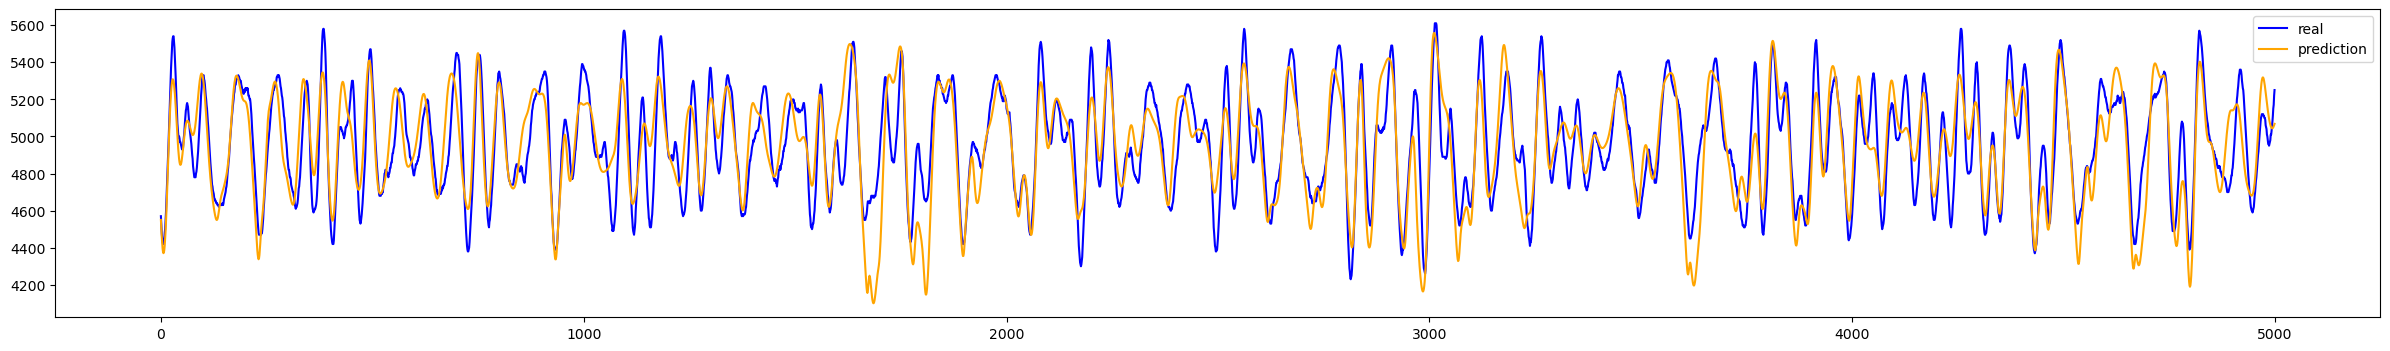

Acc: 0.9992395355499224


In [39]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force250_步长3.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长8）

In [40]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 6900, 7500, 12500)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_LSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 6600, 7500, 12500)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_LSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 6900, 7500, 12500)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_LSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/30


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 1s - loss: 0.0524 - val_loss: 0.0499 - 1s/epoch - 92ms/step
Epoch 2/30
12/12 - 0s - loss: 0.0392 - val_loss: 0.0424 - 317ms/epoch - 26ms/step
Epoch 3/30
12/12 - 0s - loss: 0.0344 - val_loss: 0.0386 - 305ms/epoch - 25ms/step
Epoch 4/30
12/12 - 0s - loss: 0.0312 - val_loss: 0.0352 - 314ms/epoch - 26ms/step
Epoch 5/30
12/12 - 0s - loss: 0.0283 - val_loss: 0.0318 - 311ms/epoch - 26ms/step
Epoch 6/30
12/12 - 0s - loss: 0.0253 - val_loss: 0.0277 - 300ms/epoch - 25ms/step
Epoch 7/30
12/12 - 0s - loss: 0.0215 - val_loss: 0.0221 - 313ms/epoch - 26ms/step
Epoch 8/30
12/12 - 0s - loss: 0.0165 - val_loss: 0.0152 - 305ms/epoch - 25ms/step
Epoch 9/30
12/12 - 0s - loss: 0.0113 - val_loss: 0.0122 - 311ms/epoch - 26ms/step
Epoch 10/30
12/12 - 0s - loss: 0.0105 - val_loss: 0.0124 - 301ms/epoch - 25ms/step
Epoch 11/30
12/12 - 0s - loss: 0.0100 - val_loss: 0.0115 - 313ms/epoch - 26ms/step
Epoch 12/30
12/12 - 0s - loss: 0.0093 - val_loss: 0.0116 - 307ms/epoch - 26ms/step
Epoch 13/30
12/12 - 0s - lo

In [41]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

19/19 [==============================] - 0s 2ms/step
(600, 1)
(600, 1)
(600, 1)


In [42]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [43]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 6900, 7500, 12500)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [44]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0291 - val_loss: 0.0344 - 272ms/epoch - 91ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0276 - val_loss: 0.0200 - 41ms/epoch - 14ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0176 - val_loss: 0.0212 - 35ms/epoch - 12ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0154 - val_loss: 0.0205 - 39ms/epoch - 13ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0164 - val_loss: 0.0232 - 35ms/epoch - 12ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0183 - val_loss: 0.0219 - 36ms/epoch - 12ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0164 - val_loss: 0.0210 - 39ms/epoch - 13ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0151 - val_loss: 0.0207 - 40ms/epoch - 13ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0150 - val_loss: 0.0209 - 40ms/epoch - 13ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0157 - val_loss: 0.0212 - 45ms/epoch - 15ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0162 - val_loss: 0.0209 - 41ms/epoch - 14ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0155 - val_loss: 0.0208 - 37ms/epoch - 12ms/step
Epoch 13/1000
3/3 - 0s -

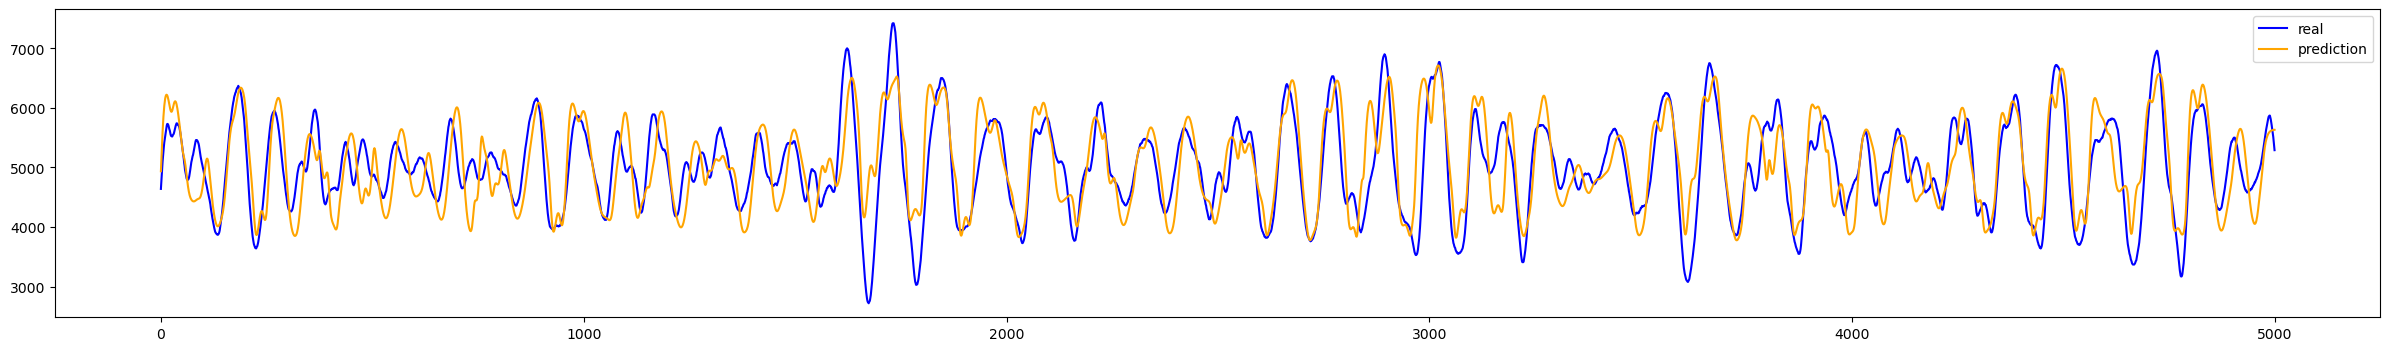

Acc: 0.9580875625038305


In [45]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force150_步长4.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [46]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[343:,:], 4, 57)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [47]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 6900, 7500, 12500)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [48]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1179 - val_loss: 0.0634 - 253ms/epoch - 84ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0666 - val_loss: 0.0685 - 40ms/epoch - 13ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0602 - val_loss: 0.0452 - 45ms/epoch - 15ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0492 - val_loss: 0.0457 - 50ms/epoch - 17ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0519 - val_loss: 0.0429 - 43ms/epoch - 14ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0463 - val_loss: 0.0359 - 42ms/epoch - 14ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0373 - val_loss: 0.0363 - 35ms/epoch - 12ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0331 - val_loss: 0.0351 - 39ms/epoch - 13ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0287 - val_loss: 0.0323 - 35ms/epoch - 12ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0271 - val_loss: 0.0341 - 36ms/epoch - 12ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0288 - val_loss: 0.0350 - 39ms/epoch - 13ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0274 - val_loss: 0.0364 - 37ms/epoch - 12ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0250

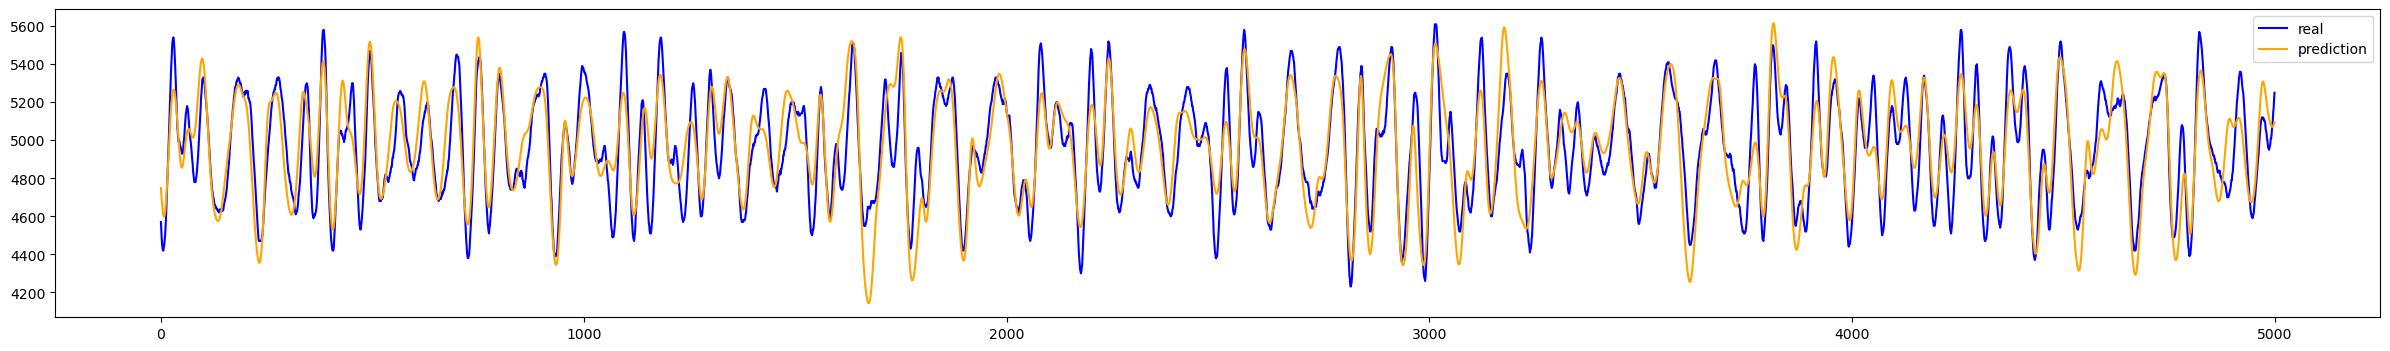

Acc: 0.9657587491555111


In [49]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force250_步长4.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')